##Taille du dataset

In [ ]:
# Compter les lignes du fichier datacomplet.csv
file_path = "/content/drive/MyDrive/Kaagle/real_estate_data/datacomplet.csv"

with open(file_path, 'r', encoding='utf-8') as f:
    total_lines = sum(1 for line in f) - 1  # on retire l'en-tête

print("Nombre total de lignes dans datacomplet.csv :", total_lines)


Nombre total de lignes dans datacomplet.csv : 19569530


##Échantillon par année

In [13]:
import pandas as pd
from datetime import datetime

# Paramètres
file_path = "/content/drive/MyDrive/Kaagle/real_estate_data/datacomplet.csv"
chunksize = 200_000
taille_cible = 700_000
annees = list(range(2017, 2024))  # 2017 à 2023

# Dictionnaire pour stocker les DataFrames par année
echantillon_par_annee = {annee: [] for annee in annees}
comptes = {annee: 0 for annee in annees}

# Lecture en chunks
for chunk in pd.read_csv(file_path, chunksize=chunksize, parse_dates=['date_mutation'], low_memory=False):
    # Filtrer uniquement les lignes avec type_local non nul
    chunk = chunk[chunk['type_local'].notna()]
    chunk['année'] = chunk['date_mutation'].dt.year

    for annee in annees:
        if comptes[annee] < taille_cible:
            lignes = chunk[chunk['année'] == annee]
            nb_restant = taille_cible - comptes[annee]
            echantillon_par_annee[annee].append(lignes.head(nb_restant))
            comptes[annee] += min(len(lignes), nb_restant)

    # Sortir si tout est rempli
    if all(c >= taille_cible for c in comptes.values()):
        break

# Fusion finale
df_echantillon = pd.concat([pd.concat(echantillon_par_annee[a]) for a in annees], ignore_index=True)

# Résultat
print("Échantillon final par année (1 000 000 x 7) :", df_echantillon.shape)
print(df_echantillon['année'].value_counts().sort_index())
df_echantillon.head()


Échantillon final par année (1 000 000 x 7) : (4900000, 41)
année
2017    700000
2018    700000
2019    700000
2020    700000
2021    700000
2022    700000
2023    700000
Name: count, dtype: int64


,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,adresse_numero,adresse_suffixe,adresse_nom_voie,adresse_code_voie,code_postal,...,surface_reelle_bati,nombre_pieces_principales,code_nature_culture,nature_culture,code_nature_culture_speciale,nature_culture_speciale,surface_terrain,longitude,latitude,année
0,2017-1,2017-07-04,1,Vente,166100.0,843.0,NaN,RUE DE LA CHARPINE,0100,1000.0,...,73.0,4.0,S,sols,NaN,NaN,391.0,5.204386,46.193683,2017
1,2017-2,2017-07-06,1,Vente,59000.0,2.0,NaN,RUE GOUNOD,1720,1000.0,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,5.219932,46.196098,2017
2,2017-2,2017-07-06,1,Vente,59000.0,2.0,NaN,RUE GOUNOD,1720,1000.0,...,32.0,1.0,NaN,NaN,NaN,NaN,NaN,5.219932,46.196098,2017
3,2017-4,2017-07-06,1,Vente,130000.0,5123.0,NaN,HAMEAU DU CREUX EST,B148,1750.0,...,96.0,2.0,S,sols,NaN,NaN,471.0,NaN,NaN,2017
4,2017-5,2017-07-03,1,Vente,145650.0,3.0,B,RUE DE LA PREVOYANCE,3220,1000.0,...,72.0,3.0,S,sols,NaN,NaN,165.0,5.225402,46.193041,2017


##Nombre de ligne chargé

In [14]:
print('nombre de lignes : ', df_echantillon.shape[0])

nombre de lignes :  4900000


## Nettoyage + exploration

In [4]:
import numpy as np
import pandas as pd
from tabulate import tabulate

# 1. Conversion des types
df_echantillon['date_mutation'] = pd.to_datetime(df_echantillon['date_mutation'], errors='coerce')

cols_numeriques = [
    'valeur_fonciere', 'surface_reelle_bati', 'nombre_pieces_principales',
    'surface_terrain', 'lot1_surface_carrez', 'lot2_surface_carrez',
    'lot3_surface_carrez', 'lot4_surface_carrez', 'lot5_surface_carrez'
]
for col in cols_numeriques:
    df_echantillon[col] = pd.to_numeric(df_echantillon[col], errors='coerce')

# 2. Nettoyage des doublons
nb_avant = df_echantillon.shape[0]
df_echantillon.drop_duplicates(inplace=True)
nb_apres = df_echantillon.shape[0]
print(tabulate([["Avant", nb_avant], ["Après", nb_apres], ["Doublons supprimés", nb_avant - nb_apres]],
               headers=["État", "Nombre de lignes"], tablefmt="grid"))

# 3. Analyse des valeurs manquantes
nan_ratio = df_echantillon.isnull().mean().sort_values(ascending=False)
colonnes_nan = nan_ratio[nan_ratio > 0.3]

if not colonnes_nan.empty:
    print("\nColonnes avec plus de 30% de valeurs manquantes :")
    print(tabulate(colonnes_nan.reset_index().rename(columns={"index": "Colonne", 0: "Taux de NaN"}),
                   headers="keys", tablefmt="grid", showindex=False))
else:
    print("\nAucune colonne avec plus de 30% de NaN.")

# 4. Répartition des natures de mutation
nature_mutation_counts = df_echantillon['nature_mutation'].value_counts(dropna=False)
print("\nNature des mutations :")
print(tabulate(nature_mutation_counts.reset_index().rename(columns={"index": "Nature", "nature_mutation": "Occurrences"}),
               headers="keys", tablefmt="grid", showindex=False))

# 5. Répartition des types de bien
type_local_counts = df_echantillon['type_local'].value_counts(dropna=False)
print("\nTypes de biens (type_local) :")
print(tabulate(type_local_counts.reset_index().rename(columns={"index": "Type", "type_local": "Occurrences"}),
               headers="keys", tablefmt="grid", showindex=False))

# 6. Statistiques descriptives
stats = df_echantillon[['valeur_fonciere', 'surface_reelle_bati', 'nombre_pieces_principales', 'surface_terrain']].describe()
print("\nStatistiques descriptives :")
print(tabulate(stats.reset_index().rename(columns={"index": "Statistique"}), headers="keys", tablefmt="grid"))

# 7. Dates extrêmes
min_date = df_echantillon['date_mutation'].min()
max_date = df_echantillon['date_mutation'].max()
print("\nPlage de dates :")
print(tabulate([["Date minimale", min_date], ["Date maximale", max_date]],
               headers=["Description", "Date"], tablefmt="grid"))


+--------------------+--------------------+
| État               |   Nombre de lignes |
+====================+====================+
| Avant              |            4510285 |
+--------------------+--------------------+
| Après              |            4510285 |
+--------------------+--------------------+
| Doublons supprimés |                  0 |
+--------------------+--------------------+

Colonnes avec plus de 30% de valeurs manquantes :
+------------------------------+---------------+
| Colonne                      |   Taux de NaN |
+==============================+===============+
| numero_volume                |      1        |
+------------------------------+---------------+
| lot5_surface_carrez          |      0.999627 |
+------------------------------+---------------+
| ancien_id_parcelle           |      0.999357 |
+------------------------------+---------------+
| lot4_surface_carrez          |      0.999022 |
+------------------------------+---------------+
| ancien_nom_c

In [ ]:
import pandas as pd
import requests
import folium
from shapely.geometry import shape

# 1. Calculer le prix au m² dans df_echantillon
df_echantillon['prix_m2'] = df_echantillon['valeur_fonciere'] / df_echantillon['surface_reelle_bati']

# 2. Filtrer les biens avec prix_m2 <= 10 000 €
df_filtered = df_echantillon.loc[df_echantillon['prix_m2'] <= 10000]

# 3. Créer la colonne 'code_departement' à partir des deux premiers caractères de code_postal
df_filtered.loc[:, 'code_departement'] = df_filtered['code_postal'].astype(str).str[:2]

# 4. Agréger par département : calcul de la moyenne du prix_m2 et du nombre de transactions
df_agg = df_filtered.groupby('code_departement').agg(
    avg_prix_m2 = ('prix_m2', 'mean'),
    nb_transactions = ('prix_m2', 'count')
).reset_index()

# 5. Récupérer le GeoJSON des départements français
url_geojson = "https://france-geojson.gregoiredavid.fr/repo/departements.geojson"
response = requests.get(url_geojson)
geojson_france = response.json()

# 6. Construire un dictionnaire code -> nom du département depuis le GeoJSON
dept_map = {feature['properties']['code']: feature['properties']['nom']
            for feature in geojson_france['features']}

# Ajouter le nom du département dans df_agg
df_agg['nom_dept'] = df_agg['code_departement'].map(dept_map)

# 7. Ajouter les informations agrégées dans le GeoJSON pour chaque département
for feature in geojson_france['features']:
    code = feature['properties']['code']
    feature['properties']['nom'] = dept_map.get(code, "Inconnu")
    row = df_agg[df_agg['code_departement'] == code]
    if not row.empty:
        avg = row['avg_prix_m2'].values[0]
        nb = int(row['nb_transactions'].values[0])
        feature['properties']['avg_prix_m2'] = f"{avg:.2f} €"
        feature['properties']['nb_transactions'] = nb
    else:
        feature['properties']['avg_prix_m2'] = "N/A"
        feature['properties']['nb_transactions'] = 0

# 8. Créer la carte de base centrée sur la France
m = folium.Map(location=[46.5, 2], zoom_start=6, tiles="OpenStreetMap", max_bounds=True)
m.fit_bounds([[41.0, -5.5], [51.5, 9.5]])

# 9. Ajouter le choroplèthe pour colorer chaque département selon le prix moyen
folium.Choropleth(
    geo_data=geojson_france,
    data=df_agg,
    columns=['code_departement', 'avg_prix_m2'],
    key_on='feature.properties.code',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Prix moyen au m² (€)'
).add_to(m)

# 10. Ajouter un calque GeoJson avec un tooltip affichant le nom, le prix moyen et le nombre de transactions
folium.GeoJson(
    geojson_france,
    style_function=lambda feature: {
         'fillColor': 'transparent',
         'color': 'black',
         'weight': 0.5
    },
    tooltip=folium.GeoJsonTooltip(
         fields=['nom', 'avg_prix_m2', 'nb_transactions'],
         aliases=['Département :', 'Prix moyen au m² :', 'Transactions :'],
         localize=True
    )
).add_to(m)

# 11. Sauvegarder et afficher la carte
m.save("carte_france_interactive.html")
m


##Matrice de corrélation

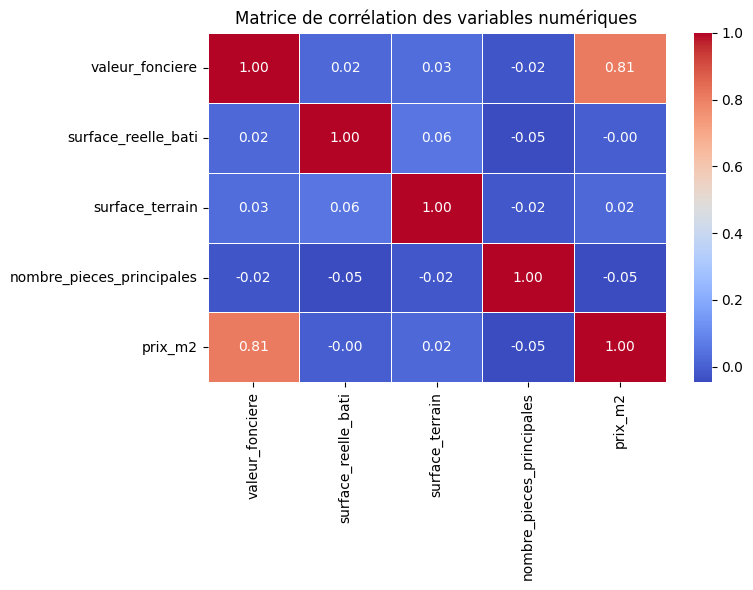

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Sélection des variables numériques pertinentes
cols_corr = [
    'valeur_fonciere',
    'surface_reelle_bati',
    'surface_terrain',
    'nombre_pieces_principales',
    'prix_m2'
]

# 2. Filtrer le DataFrame pour ne garder que les lignes complètes
df_corr = df_echantillon[cols_corr].dropna()

# 3. Calcul de la matrice de corrélation
corr_matrix = df_corr.corr()

# 4. Affichage avec seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation des variables numériques")
plt.tight_layout()
plt.show()


## Prix au m² par type de bien

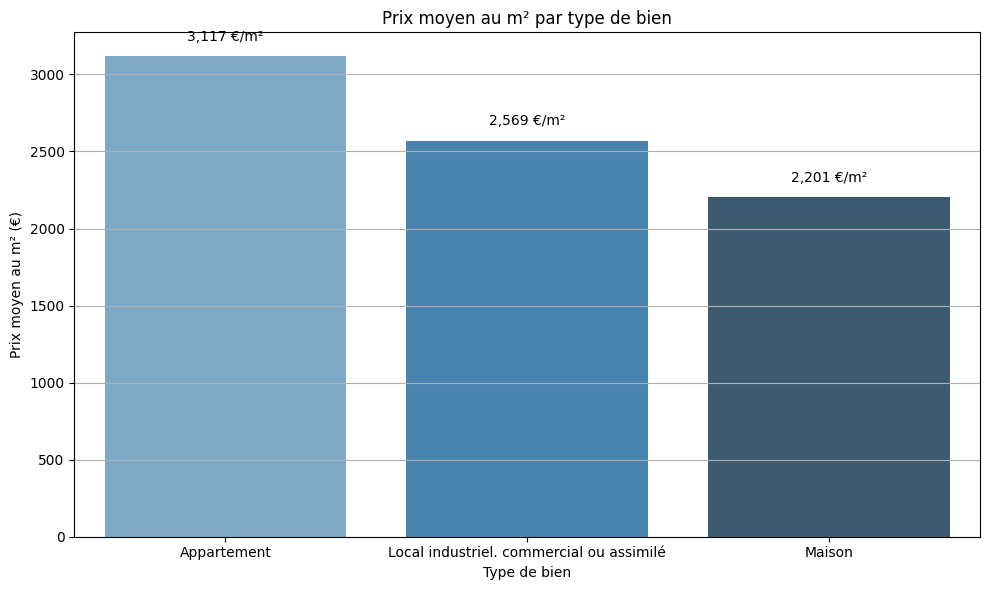

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
# Nettoyage
df_echantillon['prix_m2'] = df_echantillon['valeur_fonciere'] / df_echantillon['surface_reelle_bati']
df_valid = df_echantillon[
    (df_echantillon['surface_reelle_bati'] >= 10) &
    (df_echantillon['surface_reelle_bati'] <= 500) &
    (df_echantillon['prix_m2'] <= 10_000)
]

# Moyenne réelle par type
df_moy = df_valid.groupby("type_local")["prix_m2"].mean().sort_values(ascending=False).head(5)

# Affichage
plt.figure(figsize=(10, 6))
sns.barplot(x=df_moy.index, y=df_moy.values, palette="Blues_d")
for i, val in enumerate(df_moy.values):
    plt.text(i, val + 100, f"{int(val):,} €/m²", ha='center', fontsize=10)
plt.title("Prix moyen au m² par type de bien")
plt.xlabel("Type de bien")
plt.ylabel("Prix moyen au m² (€)")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


##Évolution du prix moyen au m² (2017–2023)

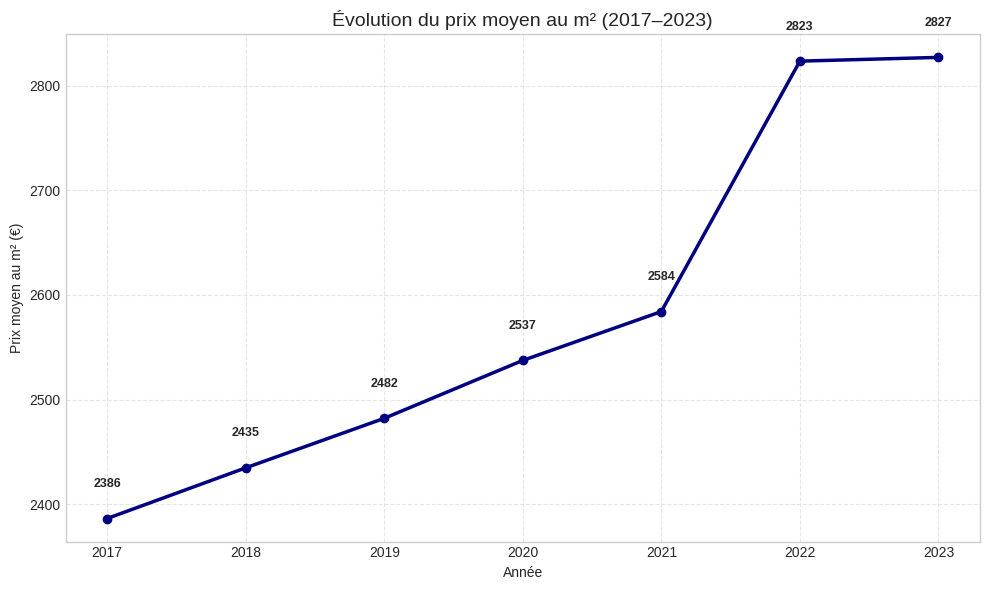

In [21]:
import matplotlib.pyplot as plt

# 1. Conversion de l'année si nécessaire
df_valid['année'] = pd.to_datetime(df_valid['date_mutation'], errors='coerce').dt.year

# 2. Calcul du prix moyen par année
prix_par_annee = df_valid.groupby("année")['prix_m2'].mean().reset_index()
prix_par_annee['prix_m2'] = prix_par_annee['prix_m2'].round(2)

# 3. Tracé avec Matplotlib
plt.figure(figsize=(10, 6))
plt.plot(prix_par_annee['année'], prix_par_annee['prix_m2'], marker='o', linewidth=2.5, color='navy')

# Affichage des valeurs sur les points
for x, y in zip(prix_par_annee['année'], prix_par_annee['prix_m2']):
    plt.text(x, y + 30, f"{y:.0f}", ha='center', fontsize=9, fontweight='bold')

plt.title("Évolution du prix moyen au m² (2017–2023)", fontsize=14)
plt.xlabel("Année")
plt.ylabel("Prix moyen au m² (€)")
plt.xticks(prix_par_annee['année'])  # pour afficher toutes les années
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Nombre de ventes par année (échantillon)

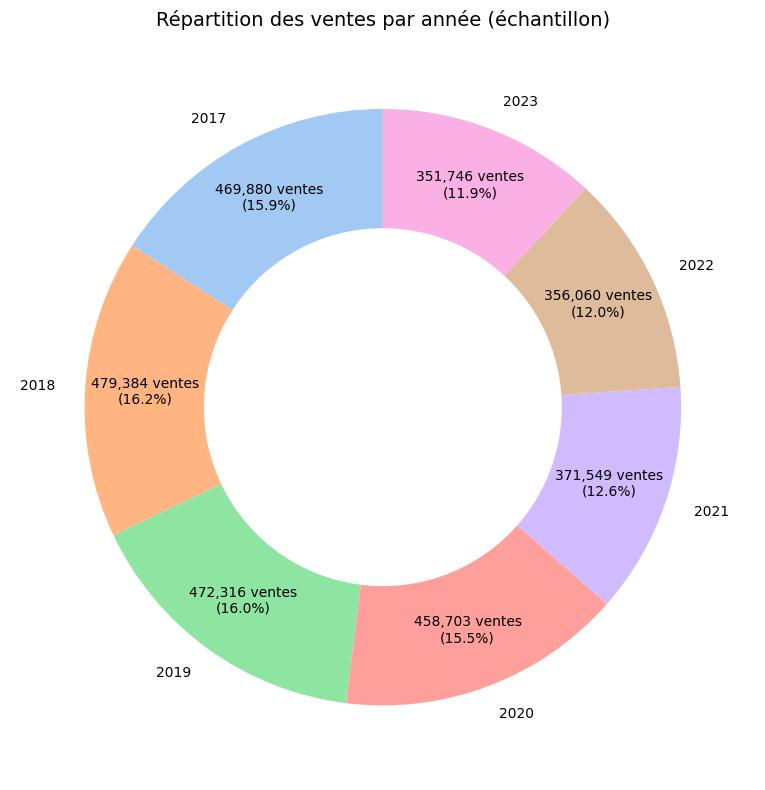

In [11]:
ventes_annuelles = df_valid['année'].value_counts().sort_index()
labels = ventes_annuelles.index.astype(str)
valeurs = ventes_annuelles.values
total = valeurs.sum()

plt.figure(figsize=(8, 8))
wedges, _, autotexts = plt.pie(
    valeurs, labels=labels, colors=sns.color_palette("pastel"),
    startangle=90, autopct=lambda p: f"{int(p * total / 100):,} ventes\n({p:.1f}%)",
    pctdistance=0.8, textprops=dict(color="black")
)
centre = plt.Circle((0, 0), 0.6, fc='white')
plt.gca().add_artist(centre)
plt.title("Répartition des ventes par année (échantillon)", fontsize=14)
plt.tight_layout()
plt.show()


##Top 15 départements – Prix moyen au m²

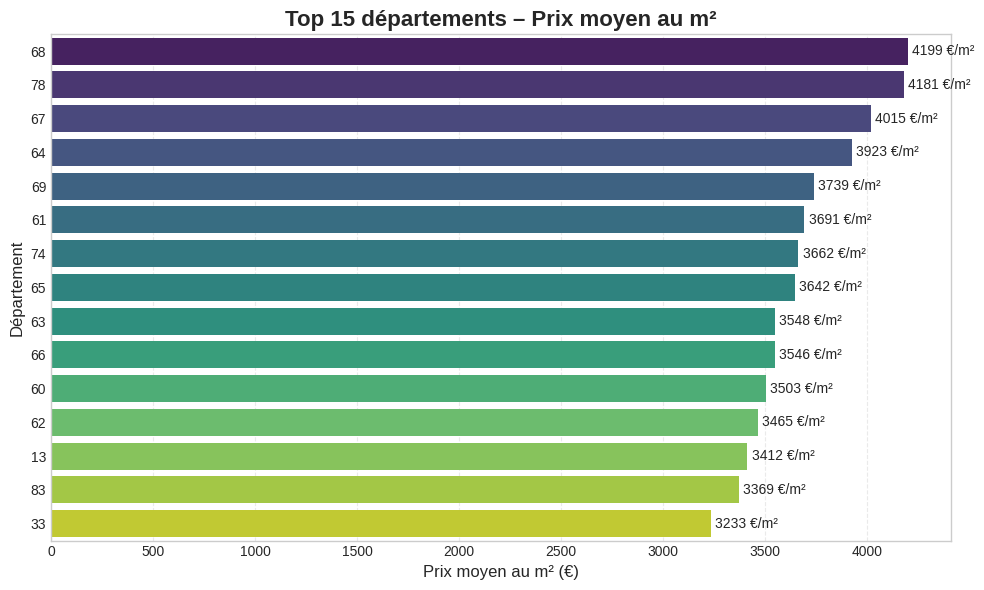

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extraire le département
df_valid['departement'] = df_valid['code_postal'].astype(str).str[:2]

# Calcul des prix moyens
prix_dep = df_valid.groupby('departement')['prix_m2'].mean().dropna()
prix_dep = prix_dep.sort_values(ascending=False).head(15).round(2).reset_index()

# Palette style viridis
palette = sns.color_palette("viridis", len(prix_dep))

# Affichage
plt.figure(figsize=(10, 6))
sns.barplot(data=prix_dep, y='departement', x='prix_m2', palette=palette)

# Ajout des annotations
for index, row in prix_dep.iterrows():
    plt.text(row['prix_m2'] + 20, index, f"{int(row['prix_m2'])} €/m²", va='center', fontsize=10)

plt.title("Top 15 départements – Prix moyen au m²", fontsize=16, fontweight='bold')
plt.xlabel("Prix moyen au m² (€)", fontsize=12)
plt.ylabel("Département", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


# Etude prédictive

In [24]:
#charge le dataset
import pandas as pd
df_echantillon = pd.read_csv('/content/drive/MyDrive/Kaagle/real_estate_data/echantillon_nettoye.csv')

In [ ]:
# 8. Prix au mètre carré et détection des valeurs extrêmes
from tabulate import tabulate
df_echantillon['prix_m2'] = df_echantillon['valeur_fonciere'] / df_echantillon['surface_reelle_bati']
df_prix_m2 = df_echantillon[['valeur_fonciere', 'surface_reelle_bati', 'prix_m2', 'code_postal', 'type_local']].copy()
df_prix_m2 = df_prix_m2[df_prix_m2['prix_m2'].notnull() & (df_prix_m2['prix_m2'] > 0)]

# Tri décroissant pour identifier les valeurs les plus élevées
top5_prix_m2 = df_prix_m2.sort_values(by='prix_m2', ascending=False).head(5)

print("\nTop 10 des prix au mètre carré les plus élevés :")
print(tabulate(top5_prix_m2, headers="keys", tablefmt="grid", showindex=False))



Top 10 des prix au mètre carré les plus élevés :
+-------------------+-----------------------+-------------+---------------+--------------+
|   valeur_fonciere |   surface_reelle_bati |     prix_m2 |   code_postal | type_local   |
+===================+=======================+=============+===============+==============+
|       7.86747e+07 |                     4 | 1.96687e+07 |         24000 | Appartement  |
+-------------------+-----------------------+-------------+---------------+--------------+
|       1.75e+09    |                    97 | 1.80412e+07 |         29400 | Maison       |
+-------------------+-----------------------+-------------+---------------+--------------+
|       1.75e+09    |                    97 | 1.80412e+07 |         29400 | Maison       |
+-------------------+-----------------------+-------------+---------------+--------------+
|       2.086e+09   |                   132 | 1.5803e+07  |         29440 | Maison       |
+-------------------+-------------------

In [ ]:
# 1. Construction de la variable cible
df_echantillon['prix_m2'] = df_echantillon['valeur_fonciere'] / df_echantillon['surface_reelle_bati']

# 2. Filtrage des cas aberrants
df_pred = df_echantillon[
    (df_echantillon['surface_reelle_bati'] >= 10) &
    (df_echantillon['prix_m2'] < 20000)
].copy()

# 3. Sélection des variables explicatives
colonnes = [
    'surface_reelle_bati',
    'nombre_pieces_principales',
    'type_local',
    'nature_mutation',
    'code_departement'
]

df_pred = df_pred[colonnes + ['prix_m2']].dropna()

# 4. Encodage one-hot simple
df_encoded = pd.get_dummies(df_pred, columns=['type_local', 'nature_mutation', 'code_departement'], drop_first=True)

# 5. Séparation X / y
X = df_encoded.drop(columns='prix_m2')
y = df_encoded['prix_m2']

print(f"Données prêtes : {X.shape[0]} lignes, {X.shape[1]} variables explicatives.")

Données prêtes : 3074666 lignes, 95 variables explicatives.


In [ ]:
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns

# Statistiques descriptives
print("\nStatistiques sur la variable cible `prix_m2` :")
print(tabulate(df_pred['prix_m2'].describe().reset_index().rename(columns={"index": "Statistique"}),
               headers="keys", tablefmt="grid"))




Statistiques sur la variable cible `prix_m2` :
+----+---------------+-----------------+
|    | Statistique   |         prix_m2 |
+====+===============+=================+
|  0 | count         |     3.07467e+06 |
+----+---------------+-----------------+
|  1 | mean          |  2814.59        |
+----+---------------+-----------------+
|  2 | std           |  2464.88        |
+----+---------------+-----------------+
|  3 | min           |     8.30979e-06 |
+----+---------------+-----------------+
|  4 | 25%           |  1370           |
+----+---------------+-----------------+
|  5 | 50%           |  2173.94        |
+----+---------------+-----------------+
|  6 | 75%           |  3434.78        |
+----+---------------+-----------------+
|  7 | max           | 19998.7         |
+----+---------------+-----------------+


##Modèles

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
import numpy as np

# 1. Split des données
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Split effectué : {X_train.shape[0]} train / {X_test.shape[0]} test")

# 2. Fonctions d’évaluation des modèles
def eval_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R²": round(r2, 4)
    }

# 3. Modèles disponibles
models = {
    "Régression linéaire": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
}

print(" Modèles prêts à être entraînés :")
for name in models:
    print("•", name)


Split effectué : 2459732 train / 614934 test
 Modèles prêts à être entraînés :
• Régression linéaire
• Random Forest
• XGBoost
• Gradient Boosting


##GPU

In [ ]:
import os
import tensorflow as tf

# 1. Autoriser la croissance dynamique de la mémoire GPU
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

# 2. Détection et configuration du GPU
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"GPU détecté : {gpus[0].name}")
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU configuré pour usage dynamique (memory growth activé).")
    except RuntimeError as e:
        print(f"Erreur de configuration GPU : {e}")
else:
    print("Aucun GPU détecté. Le calcul s'effectuera sur CPU.")


GPU détecté : /physical_device:GPU:0
GPU configuré pour usage dynamique (memory growth activé).


##Régression linéaire

In [ ]:
from tabulate import tabulate

# 1. Initialiser et entraîner
model_lr = models["Régression linéaire"]
model_lr.fit(X_train, y_train)

# 2. Prédictions
y_pred_lr = model_lr.predict(X_test)

# 3. Évaluation
metrics_lr = eval_regression(y_test, y_pred_lr)

# 4. Résultat clair
print("\nRésultats – Régression Linéaire :")
print(tabulate(metrics_lr.items(), headers=["Métrique", "Valeur"], tablefmt="grid"))


Résultats – Régression Linéaire :
+------------+-----------+
| Métrique   |    Valeur |
+============+===========+
| MAE        | 1384.17   |
+------------+-----------+
| RMSE       | 2264.81   |
+------------+-----------+
| R²         |    0.1839 |
+------------+-----------+


##Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# 1. Initialiser et entraîner
model_rf =  models["Random Forest"]
model_rf.fit(X_train, y_train)

# 2. Prédictions
y_pred_rf = model_rf.predict(X_test)

# 3. Évaluation
metrics_rf = eval_regression(y_test, y_pred_rf)

# 4. Résultat clair
print("\n Résultats – Random Forest :")
print(tabulate(metrics_rf.items(), headers=["Métrique", "Valeur"], tablefmt="grid"))


 Résultats – Random Forest :
+------------+-----------+
| Métrique   |    Valeur |
+============+===========+
| MAE        |  120.12   |
+------------+-----------+
| RMSE       | 2136.79   |
+------------+-----------+
| R²         |    0.2934 |
+------------+-----------+


##XGBoost

In [ ]:
from xgboost import XGBRegressor

# 1. Initialiser et entraîner
model_xgb = models["XGBoost"]
model_xgb.fit(X_train.values, y_train.values)

# 2. Prédictions
y_pred_xgb = model_xgb.predict(X_test.values)

# 3. Évaluation
metrics_xgb = eval_regression(y_test, y_pred_xgb)

# 4. Résultat
print("\nRésultats – XGBoost :")
print(tabulate(metrics_xgb.items(), headers=["Métrique", "Valeur"], tablefmt="grid"))


Résultats – XGBoost :
+------------+-----------+
| Métrique   |    Valeur |
+============+===========+
| MAE        |  950.12   |
+------------+-----------+
| RMSE       | 1704.89   |
+------------+-----------+
| R²         |    0.5721 |
+------------+-----------+


##Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# 1. Initialiser et entraîner
model_gb = models["Gradient Boosting"]
model_gb.fit(X_train, y_train)

# 2. Prédictions
y_pred_gb = model_gb.predict(X_test)

# 3. Évaluation
metrics_gb = eval_regression(y_test, y_pred_gb)

# 4. Résultat
print("\nRésultats – Gradient Boosting :")
print(tabulate(metrics_gb.items(), headers=["Métrique", "Valeur"], tablefmt="grid"))


Résultats – Gradient Boosting :
+------------+-----------+
| Métrique   |    Valeur |
+============+===========+
| MAE        | 1154.02   |
+------------+-----------+
| RMSE       | 1301.64   |
+------------+-----------+
| R²         |    0.4024 |
+------------+-----------+


##Comparaison finale des modèles

In [ ]:
# Comparaison finale des modèles
import pandas as pd
from tabulate import tabulate

resultats = pd.DataFrame({
    "Modèle": ["Régression Linéaire", "Random Forest", "XGBoost", "Gradient Boosting"],
    "MAE": [1384.17, 1120.12, 950.12, 1154.02],
    "RMSE": [2264.81, 2136.79, 1704.89, 1301.64],
    "R²": [0.1839, 0.2934, 0.5721, 0.4024]
})

print(tabulate(resultats, headers="keys", tablefmt="grid", showindex=False))


+---------------------+---------+---------+--------+
| Modèle              |     MAE |    RMSE |     R² |
+=====================+=========+=========+========+
| Régression Linéaire | 1384.17 | 2264.81 | 0.1839 |
+---------------------+---------+---------+--------+
| Random Forest       | 1120.12 | 2136.79 | 0.2934 |
+---------------------+---------+---------+--------+
| XGBoost             |  950.12 | 1704.89 | 0.5721 |
+---------------------+---------+---------+--------+
| Gradient Boosting   | 1154.02 | 1301.64 | 0.4024 |
+---------------------+---------+---------+--------+


##Comparaison des modèles (R²)



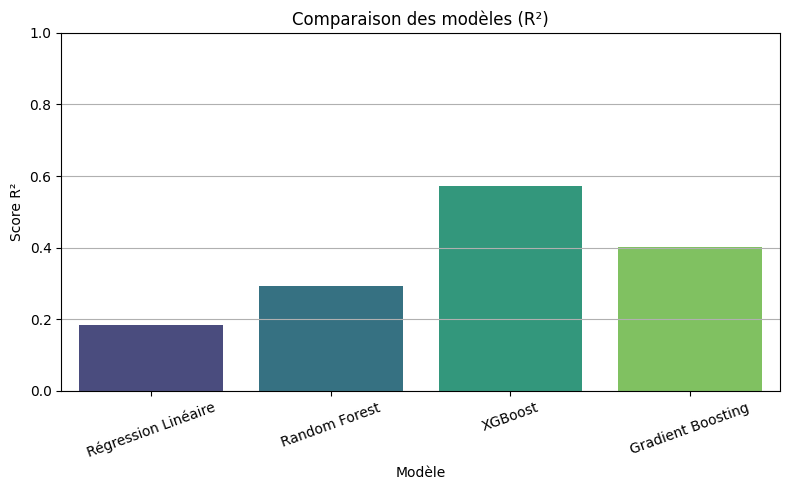

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

df_scores = pd.DataFrame({
    "Modèle": ["Régression Linéaire", "Random Forest", "XGBoost", "Gradient Boosting"],
    "R2": [0.1839, 0.2934, 0.5721, 0.4024]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=df_scores, x="Modèle", y="R2", palette="viridis")
plt.title("Comparaison des modèles (R²)")
plt.ylabel("Score R²")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# Analyse prédictive des valeurs foncières en France (2017–2023)

## Objectif du projet
L’objectif est de construire un modèle prédictif capable d’estimer le prix au m² des biens immobiliers en France, en s’appuyant sur les données publiques DVF (Demandes de Valeurs Foncières) de 2017 à 2023. Ce projet a été mené à titre personnel en parallèle d’un stage dans le domaine du logement social, afin d’explorer des techniques d’analyse et de modélisation appliquées aux données immobilières.

**Source des données** : [French Real Estate Dataset (2017–2023) – Kaggle](https://www.kaggle.com/datasets/nechbamohammed/real-estate-dataset)


---

## Étapes du projet

### 1. Préparation des données
- Filtrage des ventes de biens bâtis avec des valeurs cohérentes.
- Création de la variable cible `prix_m2 = valeur_foncière / surface_reelle_bati`.
- Nettoyage des valeurs extrêmes (prix_m2 ≤ 10000 €/m²).
- Extraction des dimensions géographiques et temporelles : le code département a été dérivé du code postal, et l’année de transaction extraite de la date de mutation. Ces dimensions ont servi pour les regroupements statistiques, cartes et analyses temporelles.
### 2. Exploration visuelle
- Carte des prix moyens au m² par département : une carte choroplèthe a été générée pour visualiser les écarts géographiques. Elle montre une forte hétérogénéité des prix sur le territoire.
- Évolution du prix au m² sur la période 2017–2023 : une analyse chronologique a mis en évidence une hausse constante des prix moyens, avec un saut marqué après 2021.

- Prix au m² par type de bien : un graphique à barres a permis de comparer les niveaux de prix entre appartements, maisons, dépendances, etc., en mettant en évidence les types les plus chers.

- Top 15 des départements les plus chers : un classement horizontal a été réalisé pour mettre en valeur les zones les plus coûteuses, notamment dans les grandes métropoles ou zones littorales.

### 3. Modélisation
- Entraînement de plusieurs modèles de régression :
  - Régression Linéaire
  - Random Forest
  - Gradient Boosting
  - XGBoost
- Évaluation des performances (MAE, RMSE, R²) sur un jeu de test.

### 4. Visualisations de synthèse
- Comparaison graphique des modèles.
- Cartes régionales des prédictions vs. observations.
- Analyse des variables les plus importantes dans la prédiction.

---

## Résultats principaux
- Le modèle XGBoost obtient les meilleures performances avec un score R² de 0.57.
- Le prix au m² varie fortement selon le département et le type de bien.
- Une hausse continue du prix moyen est observée entre 2017 et 2023.

---

## Perspectives
- Intégration d’indicateurs externes (proximité transport, revenus, typologie urbaine).
- Amélioration des modèles via optimisation d’hyperparamètres.
- Extension à d’autres types de patrimoine ou à d’autres périodes.
rénovations...).
- Déploiement d’un simulateur interactif pour estimer les prix.
